# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
# Import library untuk manipulasi data
import pandas as pd
import numpy as np

# Import library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Import library untuk preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Mengabaikan warnings untuk kebersihan output
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
df = pd.read_csv('weather_classification_data.csv')

# Menampilkan 5 baris pertama
df.head(10)

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy
5,32.0,55,3.5,26.0,overcast,1010.03,2,Summer,5.0,inland,Cloudy
6,-2.0,97,8.0,86.0,overcast,990.87,1,Winter,4.0,inland,Snowy
7,3.0,85,6.0,96.0,partly cloudy,984.46,1,Winter,3.5,inland,Snowy
8,3.0,83,6.0,66.0,overcast,999.44,0,Winter,1.0,mountain,Snowy
9,28.0,74,8.5,107.0,clear,1012.13,8,Winter,7.5,coastal,Sunny


In [ ]:
# Menampilkan informasi dataset
print("Informasi Dataset : ")
df.info(10)

Informasi Dataset : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

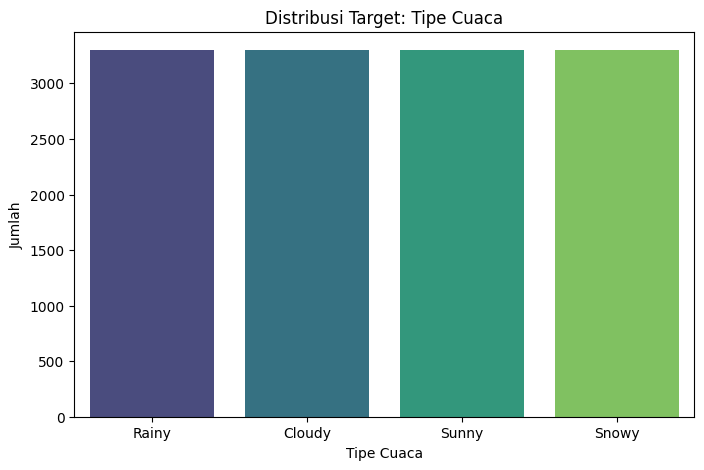

In [ ]:
# 4.1 Pengecekan Distribusi Target (Weather Type)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Weather Type', palette='viridis')
plt.title('Distribusi Target: Tipe Cuaca')
plt.xlabel('Tipe Cuaca')
plt.ylabel('Jumlah')
plt.show()

In [ ]:
# 4.2 Pengecekan Statistik Deskriptif
display(df.describe())

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


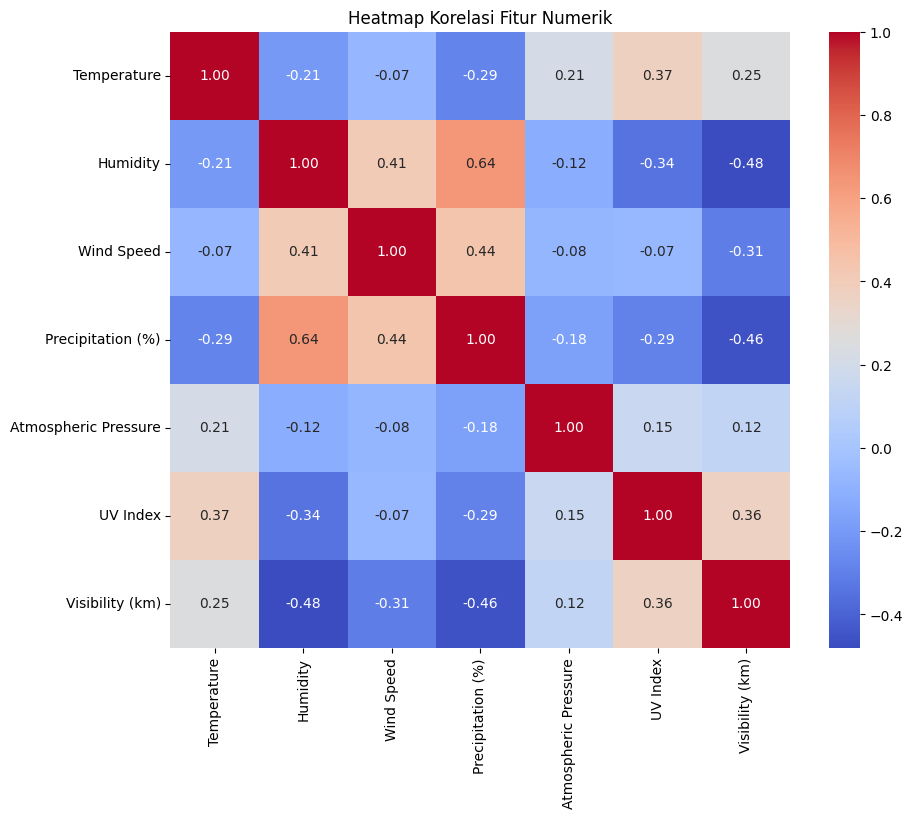

In [ ]:
# 4.3 Analisis Korelasi Fitur Numerik
plt.figure(figsize=(10, 8))
numeric_columns = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()

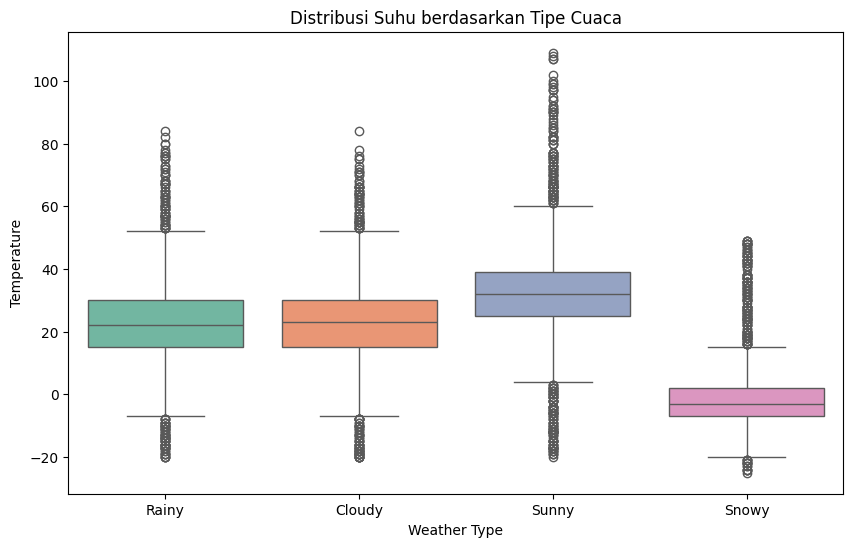

In [ ]:
# 4.4 Distribusi Suhu Berdasarkan Cuaca
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Weather Type', y='Temperature', palette='Set2')
plt.title('Distribusi Suhu berdasarkan Tipe Cuaca')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
# 5.1 Cek dan Penanganan Missing Values
print("Missing values pada setiap kolom:")
print(df.isnull().sum())
# Dataset ini kebetulan sangat bersih dari missing values.

Missing values pada setiap kolom:
Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64


In [ ]:
# 5.2 Cek dan Penanganan Duplikat
jumlah_duplikat = df.duplicated().sum()
print(f"\nJumlah data duplikat: {jumlah_duplikat}")
if jumlah_duplikat > 0:
    df = df.drop_duplicates()
    print("Data duplikat telah dihapus.")



Jumlah data duplikat: 0


In [ ]:
# 5.3 Encoding Data Kategorikal (Fitur)
# Kita menggunakan One-Hot Encoding untuk fitur agar model tidak menganggap adanya urutan (hierarki)
categorical_features = ['Cloud Cover', 'Season', 'Location']
df_processed = pd.get_dummies(df, columns=categorical_features, drop_first=True)

In [ ]:
# 5.4 Encoding Target (Weather Type)
# Mengubah target menjadi numerik menggunakan LabelEncoder
label_encoder = LabelEncoder()
df_processed['Weather Type'] = label_encoder.fit_transform(df_processed['Weather Type'])

In [ ]:
# Mari kita simpan mapping labelnya untuk keperluan inference nanti
mapping_label = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("\nMapping Label Cuaca:", mapping_label)


Mapping Label Cuaca: {'Cloudy': np.int64(0), 'Rainy': np.int64(1), 'Snowy': np.int64(2), 'Sunny': np.int64(3)}


In [ ]:
# 5.5 Scaling (Standarisasi Fitur Numerik)
# Menstandarkan skala numerik menggunakan StandardScaler
scaler = StandardScaler()
numeric_features = ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
                    'Atmospheric Pressure', 'UV Index', 'Visibility (km)']

df_processed[numeric_features] = scaler.fit_transform(df_processed[numeric_features])

In [ ]:
# Menampilkan hasil akhir
print("\n--- Data Setelah Preprocessing ---")
df_processed.head(10)


--- Data Setelah Preprocessing ---


,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Weather Type,Cloud Cover_cloudy,Cloud Cover_overcast,Cloud Cover_partly cloudy,Season_Spring,Season_Summer,Season_Winter,Location_inland,Location_mountain
0,-0.294931,0.212404,-0.048086,0.887629,0.134203,-0.520104,-0.582231,1,False,False,True,False,False,True,True,False
1,1.143035,1.351385,-0.192836,0.543291,0.150602,0.776424,1.345768,0,False,False,True,True,False,False,True,False
2,0.625367,-0.233285,-0.409962,-1.178401,0.346579,0.257813,0.010999,3,False,False,False,True,False,False,False,True
3,1.085516,0.707613,-1.206089,0.887629,0.549008,0.776424,-1.323769,3,False,False,False,True,False,False,False,False
4,0.452811,0.261924,1.037543,0.386773,-0.407490,-0.779410,-0.878846,1,False,True,False,False,False,True,False,True
5,0.740404,-0.678973,-0.916588,-0.865366,0.112965,-0.520104,-0.137308,0,False,True,False,False,True,False,True,False
6,-1.215229,1.400906,-0.265211,1.012843,-0.402114,-0.779410,-0.433923,2,False,True,False,False,False,True,True,False
7,-0.927636,0.806655,-0.554712,1.325878,-0.574434,-0.779410,-0.582231,2,False,False,True,False,False,True,True,False
8,-0.927636,0.707613,-0.554712,0.386773,-0.171726,-1.038715,-1.323769,2,False,True,False,False,False,True,False,True
9,0.510330,0.261924,-0.192836,1.670216,0.169420,1.035729,0.604230,3,False,False,False,False,False,True,False,False


In [ ]:
# 5.6 Menyimpan Data yang Siap Dilatih
# Simpan dataset ini ke dalam folder yang ditentukan pada struktur proyek
import os
os.makedirs('namadataset_preprocessing', exist_ok=True)
df_processed.to_csv('namadataset_preprocessing/weather_processed.csv', index=False)
print("\nDataset berhasil diproses dan disimpan sebagai 'weather_processed.csv'!")



Dataset berhasil diproses dan disimpan sebagai 'weather_processed.csv'!
